In [1]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time
from sklearn.ensemble import HistGradientBoostingRegressor




In [2]:

df = pd.read_csv("../data/house_prices.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
# Missing values in each column

missing = df.isna().sum().sort_values(ascending=False)

print(missing)

Plot Area            187531
Dimensions           187531
Society              109678
Super Area           107685
Car Parking          103357
overlooking           81436
Carpet Area           80673
facing                70233
Ownership             65517
Balcony               48935
Price (in rupees)     17665
Floor                  7077
Description            3023
Furnishing             2897
Bathroom                828
Status                  615
Transaction              83
Amount(in rupees)         0
Title                     0
Index                     0
location                  0
dtype: int64


In [4]:
# Missing percentage

missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

print(missing_percent)

Plot Area            100.000000
Dimensions           100.000000
Society               58.485264
Super Area            57.422506
Car Parking           55.114621
overlooking           43.425354
Carpet Area           43.018488
facing                37.451408
Ownership             34.936624
Balcony               26.094352
Price (in rupees)      9.419776
Floor                  3.773776
Description            1.612000
Furnishing             1.544811
Bathroom               0.441527
Status                 0.327946
Transaction            0.044259
Amount(in rupees)      0.000000
Title                  0.000000
Index                  0.000000
location               0.000000
dtype: float64


In [5]:
# Check unique values in important columns

columns_to_check = [
    "Status",
    "Transaction",
    "Furnishing",
    "Ownership",
    "facing",
    "Bathroom",
    "Balcony",
    "Floor",
    "Car Parking"
]

for col in columns_to_check:
    print(f"\n{'='*50}")
    print(f"{col}")
    print(f"{'='*50}")
    print(df[col].value_counts(dropna=False).head(15))


Status
Status
Ready to Move    186916
NaN                 615
Name: count, dtype: int64

Transaction
Transaction
Resale          144172
New Property     42565
Other              709
NaN                 83
Rent/Lease           2
Name: count, dtype: int64

Furnishing
Furnishing
Semi-Furnished    88318
Unfurnished       76154
Furnished         20162
NaN                2897
Name: count, dtype: int64

Ownership
Ownership
Freehold                112229
NaN                      65517
Leasehold                 5285
Co-operative Society      3431
Power Of Attorney         1069
Name: count, dtype: int64

facing
facing
NaN             70233
East            54741
North - East    24220
North           16533
West             8574
South            4694
North - West     3843
South - East     2622
South -West      2071
Name: count, dtype: int64

Bathroom
Bathroom
2       93007
3       55781
1       18654
4       15600
5        3343
NaN       828
6         209
> 10       35
7          35
10         14


In [6]:
# ==========================================
# Step 1: Clean the target price
# ==========================================

def parse_amount(x):
    if not isinstance(x, str):
        return None

    x = x.strip().lower()

    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 100000

        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 10000000

        return float(x.replace(",", ""))

    except ValueError:
        return None


# Create cleaned target column
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)

# Remove rows where price could not be converted
df = df.dropna(subset=["price_clean"]).copy()

print("Dataset shape after cleaning price:", df.shape)

print("\nSample of cleaned prices:")
print(df[["Amount(in rupees)", "price_clean"]].head(10))

Dataset shape after cleaning price: (177847, 22)

Sample of cleaned prices:
  Amount(in rupees)  price_clean
0           42 Lac     4200000.0
1           98 Lac     9800000.0
2          1.40 Cr    14000000.0
3           25 Lac     2500000.0
4          1.60 Cr    16000000.0
5           45 Lac     4500000.0
6         16.5 Lac     1650000.0
7           60 Lac     6000000.0
8           60 Lac     6000000.0
9          1.60 Cr    16000000.0


In [7]:
# ==========================================
# Step 2: Clean Carpet Area
# ==========================================

def parse_area(x):
    if not isinstance(x, str):
        return None

    x = x.strip().lower()

    try:
        if "sqm" in x:
            value = float(x.replace("sqm", "").strip())
            return value * 10.764

        if "sqft" in x:
            value = float(x.replace("sqft", "").strip())
            return value

        return float(x.replace(",", ""))

    except ValueError:
        return None


# Create cleaned carpet area column
df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)

print("Sample of cleaned carpet areas:")
print(df[["Carpet Area", "carpet_area_sqft"]].head(10))

print("\nMissing carpet areas:")
print(df["carpet_area_sqft"].isna().sum())

Sample of cleaned carpet areas:
  Carpet Area  carpet_area_sqft
0    500 sqft             500.0
1    473 sqft             473.0
2    779 sqft             779.0
3    530 sqft             530.0
4    635 sqft             635.0
5         NaN               NaN
6    550 sqft             550.0
7         NaN               NaN
8         NaN               NaN
9    900 sqft             900.0

Missing carpet areas:
80991


In [8]:
# ==========================================
# Step 3: Clean Floor
# ==========================================

def parse_floor(x):
    if not isinstance(x, str):
        return None

    x = x.strip().lower()

    # Ground floor = 0
    if "ground" in x:
        return 0

    # Extract the first number
    try:
        return float(x.split(" out of ")[0].strip())
    except (ValueError, IndexError):
        return None


# Create cleaned floor column
df["floor_num"] = df["Floor"].apply(parse_floor)

print("Sample of cleaned floors:")
print(df[["Floor", "floor_num"]].head(15))

print("\nMissing floors:")
print(df["floor_num"].isna().sum())

Sample of cleaned floors:
              Floor  floor_num
0      10 out of 11       10.0
1       3 out of 22        3.0
2      10 out of 29       10.0
3        1 out of 3        1.0
4      20 out of 42       20.0
5        2 out of 7        2.0
6        4 out of 5        4.0
7   Ground out of 7        0.0
8   Ground out of 2        0.0
9       3 out of 27        3.0
10      6 out of 20        6.0
11     16 out of 24       16.0
12      8 out of 20        8.0
13     18 out of 27       18.0
14       2 out of 3        2.0

Missing floors:
7284


In [9]:
# ==========================================
# STEP 4: Complete Data Cleaning
# ==========================================

# 1. Bathroom → numeric + median
df["Bathroom"] = pd.to_numeric(df["Bathroom"], errors="coerce")
df["Bathroom"] = df["Bathroom"].fillna(df["Bathroom"].median())

# 2. Balcony → numeric + median
df["Balcony"] = pd.to_numeric(df["Balcony"], errors="coerce")
df["Balcony"] = df["Balcony"].fillna(df["Balcony"].median())

# 3. Floor → median
df["floor_num"] = df["floor_num"].fillna(df["floor_num"].median())

# 4. Carpet Area → median
df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(
    df["carpet_area_sqft"].median()
)

# 5. Furnishing → fill missing
df["Furnishing"] = df["Furnishing"].fillna("Unknown")

# 6. Transaction → fill missing
df["Transaction"] = df["Transaction"].fillna("Unknown")

# 7. Ownership → fill missing
df["Ownership"] = df["Ownership"].fillna("Unknown")

# 8. Facing → fill missing
df["facing"] = df["facing"].fillna("Unknown")

# 9. Location → keep top 50 locations
top_locations = df["location"].value_counts().head(50).index

df["location_grouped"] = df["location"].where(
    df["location"].isin(top_locations),
    "Other"
)

# 10. Drop useless / high-missing columns
columns_to_drop = [
    "Index",
    "Title",
    "Description",
    "Price (in rupees)",
    "Plot Area",
    "Dimensions",
    "Society",
    "Super Area",
    "Car Parking",
    "overlooking",
    "Status",
    "Carpet Area",
    "Floor",
    "location",
    "Amount(in rupees)"
]

df = df.drop(columns=columns_to_drop, errors="ignore")

# Final check
print("Final shape:", df.shape)
print("\nRemaining columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

Final shape: (177847, 10)

Remaining columns:
['Transaction', 'Furnishing', 'facing', 'Bathroom', 'Balcony', 'Ownership', 'price_clean', 'carpet_area_sqft', 'floor_num', 'location_grouped']

Missing values:
Transaction         0
Furnishing          0
facing              0
Bathroom            0
Balcony             0
Ownership           0
price_clean         0
carpet_area_sqft    0
floor_num           0
location_grouped    0
dtype: int64


In [10]:
# Check final dataset
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSample:")
display(df.head())

Shape: (177847, 10)

Columns:
['Transaction', 'Furnishing', 'facing', 'Bathroom', 'Balcony', 'Ownership', 'price_clean', 'carpet_area_sqft', 'floor_num', 'location_grouped']

Data Types:
Transaction             str
Furnishing              str
facing                  str
Bathroom            float64
Balcony             float64
Ownership               str
price_clean         float64
carpet_area_sqft    float64
floor_num           float64
location_grouped        str
dtype: object

Missing Values:
Transaction         0
Furnishing          0
facing              0
Bathroom            0
Balcony             0
Ownership           0
price_clean         0
carpet_area_sqft    0
floor_num           0
location_grouped    0
dtype: int64

Sample:


,Transaction,Furnishing,facing,Bathroom,Balcony,Ownership,price_clean,carpet_area_sqft,floor_num,location_grouped
0,Resale,Unfurnished,Unknown,1.0,2.0,Unknown,4200000.0,500.0,10.0,thane
1,Resale,Semi-Furnished,East,2.0,2.0,Freehold,9800000.0,473.0,3.0,thane
2,Resale,Unfurnished,East,2.0,2.0,Freehold,14000000.0,779.0,10.0,thane
3,Resale,Unfurnished,Unknown,1.0,1.0,Unknown,2500000.0,530.0,1.0,thane
4,Resale,Unfurnished,West,2.0,2.0,Co-operative Society,16000000.0,635.0,20.0,thane


In [11]:

# Features & Target
X = df.drop(columns=['price_clean'])
y = df['price_clean']

# Identify columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

print("Categorical columns:", list(categorical_cols))
print("Numerical columns:", list(numerical_cols))

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nX_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Categorical columns: ['Transaction', 'Furnishing', 'facing', 'Ownership', 'location_grouped']
Numerical columns: ['Bathroom', 'Balcony', 'carpet_area_sqft', 'floor_num']

X_train: (142277, 9)
X_test : (35570, 9)
y_train: (142277,)
y_test : (35570,)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_19880\3352718741.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


In [12]:

# Log transform target
y_log = np.log1p(df['price_clean'])

# Split
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (142277, 9)
Testing : (35570, 9)


In [13]:
# Remove extreme price outliers from training data

Q1 = y_train_log.quantile(0.01)
Q99 = y_train_log.quantile(0.99)

mask = (y_train_log >= Q1) & (y_train_log <= Q99)

X_train_clean = X_train.loc[mask]
y_train_clean = y_train_log.loc[mask]

print("Before removing outliers:", len(y_train_log))
print("After removing outliers :", len(y_train_clean))
print("Removed:", len(y_train_log) - len(y_train_clean))

Before removing outliers: 142277
After removing outliers : 139911
Removed: 2366


In [14]:
# Train final Random Forest after removing outliers

final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ))
])

start = time.time()

final_model.fit(X_train_clean, y_train_clean)

print(f"Training Time: {time.time() - start:.2f} seconds")

# Predict
y_pred_log = final_model.predict(X_test)

# Convert back to original price
y_pred_final = np.expm1(y_pred_log)
y_test_final = np.expm1(y_test_log)

# Evaluation
mae_final = mean_absolute_error(y_test_final, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test_final, y_pred_final))
r2_final = r2_score(y_test_final, y_pred_final)

print("\nFinal Random Forest Performance:")
print(f"MAE  : {mae_final:,.2f}")
print(f"RMSE : {rmse_final:,.2f}")
print(f"R²   : {r2_final:.4f}")

Training Time: 137.80 seconds

Final Random Forest Performance:
MAE  : 2,256,829.85
RMSE : 75,651,734.07
R²   : 0.0199


In [15]:
# ==========================================
# Evaluate model without extreme test prices
# ==========================================

# Convert test target from log scale to original price scale
y_test_original = np.expm1(y_test_log)

# Convert Random Forest predictions from log scale
y_pred_original = np.expm1(y_pred_log)

# Find the 99th percentile of test prices
test_threshold = y_test_original.quantile(0.99)

# Keep the normal 99% of test samples
normal_mask = y_test_original <= test_threshold

y_test_normal = y_test_original[normal_mask]
y_pred_normal = y_pred_original[normal_mask]

# Calculate metrics
mae_normal = mean_absolute_error(
    y_test_normal,
    y_pred_normal
)

rmse_normal = np.sqrt(
    mean_squared_error(
        y_test_normal,
        y_pred_normal
    )
)

r2_normal = r2_score(
    y_test_normal,
    y_pred_normal
)

print("Evaluation on 99% of test data:")
print(f"MAE  : {mae_normal:,.2f}")
print(f"RMSE : {rmse_normal:,.2f}")
print(f"R²   : {r2_normal:.4f}")

print(
    f"\nRemoved from test evaluation: "
    f"{len(y_test_original) - len(y_test_normal)}"
)

Evaluation on 99% of test data:
MAE  : 1,333,607.69
RMSE : 3,844,004.67
R²   : 0.8624

Removed from test evaluation: 247


In [17]:
# Correct Evaluation for Log-Transformed Target

# Predictions are in log scale
y_pred_log = model_log.predict(X_test)

# Convert predictions back to original price scale
y_pred = np.expm1(y_pred_log)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Final Random Forest Performance")
print("-" * 40)
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

NameError: name 'model_log' is not defined

In [18]:
# Check target distribution and extreme predictions

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison['Error'] = comparison['Actual'] - comparison['Predicted']
comparison['Abs_Error'] = abs(comparison['Error'])

print("Actual price statistics:")
print(comparison['Actual'].describe())

print("\nPredicted price statistics:")
print(comparison['Predicted'].describe())

print("\nTop 10 largest errors:")
print(
    comparison
    .sort_values('Abs_Error', ascending=False)
    .head(10)
)

NameError: name 'y_pred' is not defined

In [19]:
# Evaluation on 99% of Test Data
# Remove extreme price outliers

evaluation_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

# 99th percentile
upper_limit = evaluation_df['Actual'].quantile(0.99)

# Keep 99% of test data
evaluation_99 = evaluation_df[
    evaluation_df['Actual'] <= upper_limit
]

# Calculate metrics
mae_99 = mean_absolute_error(
    evaluation_99['Actual'],
    evaluation_99['Predicted']
)

rmse_99 = np.sqrt(
    mean_squared_error(
        evaluation_99['Actual'],
        evaluation_99['Predicted']
    )
)

r2_99 = r2_score(
    evaluation_99['Actual'],
    evaluation_99['Predicted']
)

print("Evaluation on 99% of Test Data")
print("-" * 40)
print(f"Upper price limit : {upper_limit:,.2f}")
print(f"Samples evaluated : {len(evaluation_99):,}")
print(f"Samples removed   : {len(evaluation_df) - len(evaluation_99):,}")
print(f"MAE               : {mae_99:,.2f}")
print(f"RMSE              : {rmse_99:,.2f}")
print(f"R²                : {r2_99:.4f}")

NameError: name 'y_pred' is not defined

In [20]:
# Actual vs Predicted - 99% Test Data

plt.figure(figsize=(10, 6))

plt.scatter(
    evaluation_99['Actual'],
    evaluation_99['Predicted'],
    alpha=0.5
)

# Perfect prediction line
min_value = min(
    evaluation_99['Actual'].min(),
    evaluation_99['Predicted'].min()
)

max_value = max(
    evaluation_99['Actual'].max(),
    evaluation_99['Predicted'].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices - 99% Test Data")

plt.show()

NameError: name 'plt' is not defined

In [21]:
# Residual Analysis - 99% Test Data

evaluation_99['Residual'] = (
    evaluation_99['Actual'] - evaluation_99['Predicted']
)

plt.figure(figsize=(10, 6))

plt.scatter(
    evaluation_99['Predicted'],
    evaluation_99['Residual'],
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Analysis - 99% Test Data")

plt.show()

NameError: name 'evaluation_99' is not defined

In [22]:
import joblib

# Save the trained model
joblib.dump(model_log, "house_price_random_forest.pkl")

print("Model saved successfully!")

NameError: name 'model_log' is not defined

In [ ]:
import os

print("File exists:", os.path.exists("house_price_random_forest.pkl"))
print("File size:", os.path.getsize("house_price_random_forest.pkl"), "bytes")

File exists: True
File size: 116121162 bytes


In [ ]:
# Test Prediction on a New House

new_house = pd.DataFrame({
    'Bathroom': [2],
    'Balcony': [1],
    'carpet_area_sqft': [1200],
    'floor_num': [5],
    'Transaction': ['Resale'],
    'Furnishing': ['Semi-Furnished'],
    'facing': ['East'],
    'Ownership': ['Freehold'],
    'location_grouped': ['Mumbai']
})

# Predict in log scale
prediction_log = model_log.predict(new_house)

# Convert back to original price
predicted_price = np.expm1(prediction_log)[0]

print("Predicted House Price:")
print(f"₹ {predicted_price:,.2f}")

Predicted House Price:
₹ 6,029,730.32


In [ ]:
import json

# استخراج قائمة الأماكن الفريدة وترتيبها أبجديًا
locations_list = sorted(df["location_grouped"].unique().tolist())

# حفظ القائمة في ملف locations.json داخل مجلد models
with open("../models/locations.json", "w", encoding="utf-8") as f:
    json.dump(locations_list, f, ensure_ascii=False, indent=4)

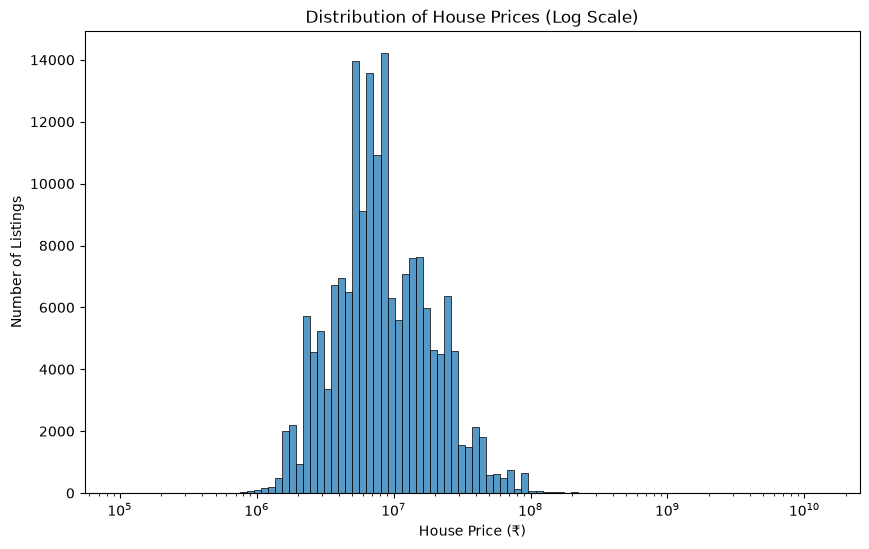

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(
    df["price_clean"],
    bins=100,
    log_scale=True
)

plt.xlabel("House Price (₹)")
plt.ylabel("Number of Listings")
plt.title("Distribution of House Prices (Log Scale)")

plt.show()


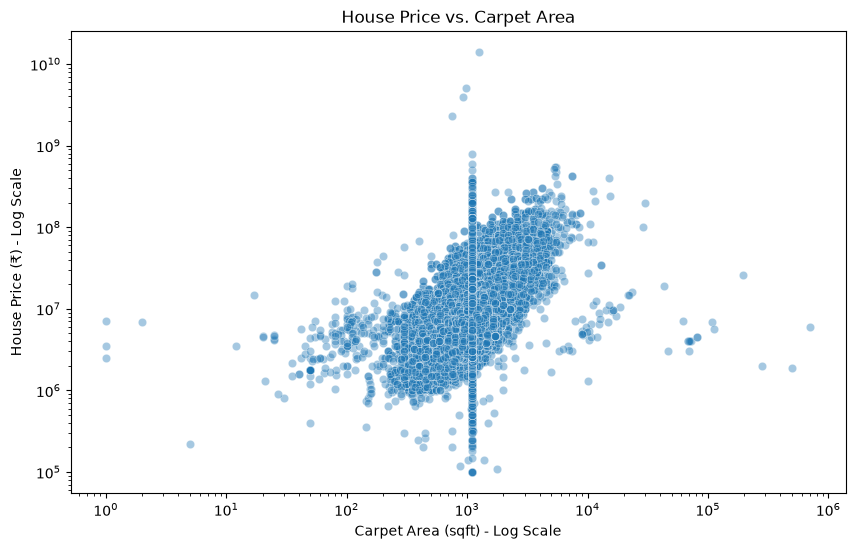

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="carpet_area_sqft",
    y="price_clean",
    alpha=0.4
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Carpet Area (sqft) - Log Scale")
plt.ylabel("House Price (₹) - Log Scale")
plt.title("House Price vs. Carpet Area")

plt.show()

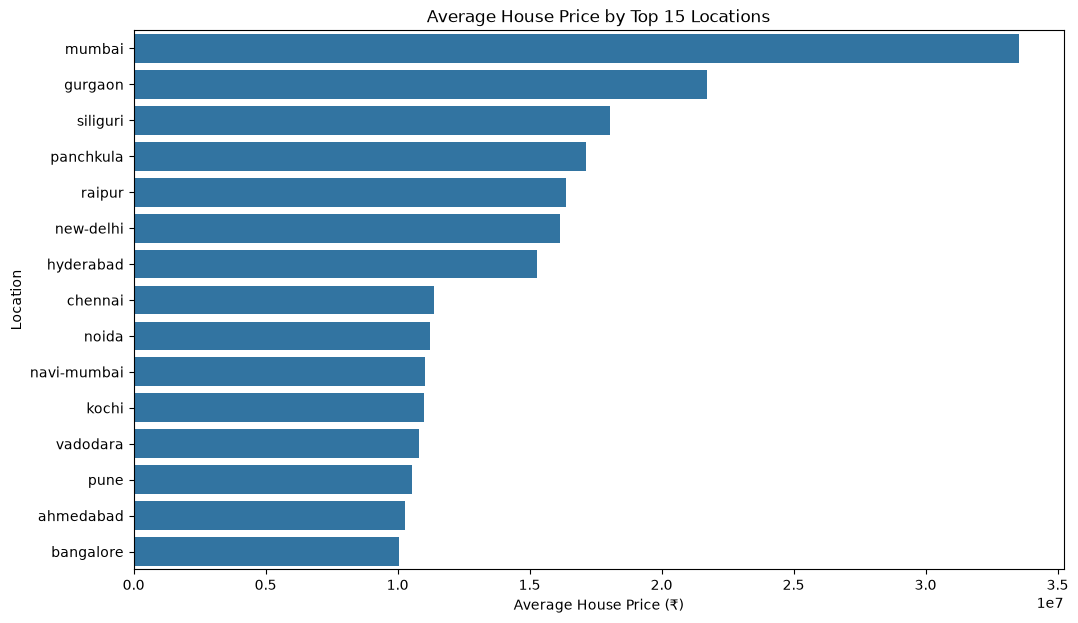

In [ ]:
top_15_locations = (
    df.groupby("location_grouped")["price_clean"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_15_locations.values,
    y=top_15_locations.index
)

plt.xlabel("Average House Price (₹)")
plt.ylabel("Location")
plt.title("Average House Price by Top 15 Locations")

plt.show()

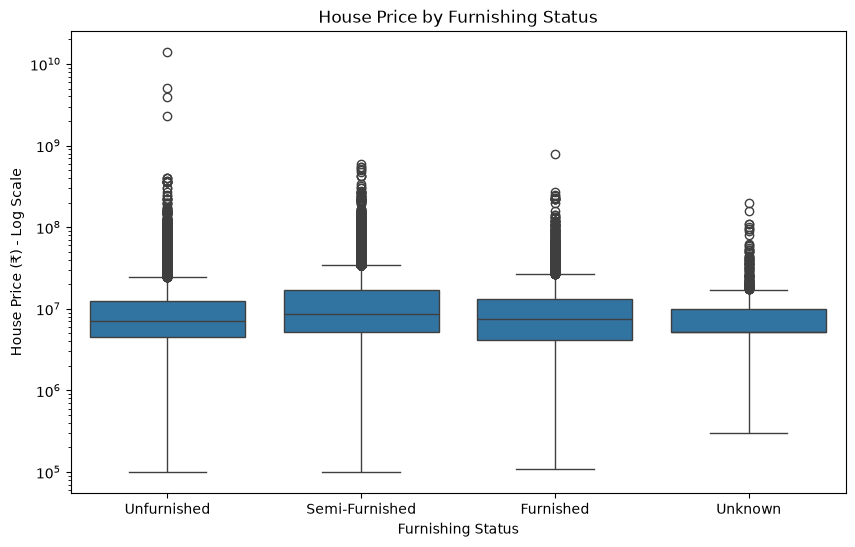

In [ ]:
### 4. Price by Furnishing Status

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Furnishing",
    y="price_clean"
)

plt.yscale("log")
plt.xlabel("Furnishing Status")
plt.ylabel("House Price (₹) - Log Scale")
plt.title("House Price by Furnishing Status")

plt.show()

In [ ]:
# ==========================================
# Model 2: Linear Regression
# ==========================================

from sklearn.linear_model import LinearRegression

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

start = time.time()

linear_model.fit(X_train_clean, y_train_clean)

print(f"Linear Regression Training Time: {time.time() - start:.2f} seconds")

# Predict in log scale
linear_pred_log = linear_model.predict(X_test)

# Convert back to original price
linear_pred = np.expm1(linear_pred_log)
y_test_original = np.expm1(y_test_log)

# Evaluation
linear_mae = mean_absolute_error(y_test_original, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test_original, linear_pred))
linear_r2 = r2_score(y_test_original, linear_pred)

print("\nLinear Regression Performance:")
print("-" * 40)
print(f"MAE  : {linear_mae:,.2f}")
print(f"RMSE : {linear_rmse:,.2f}")
print(f"R²   : {linear_r2:.4f}")

Linear Regression Training Time: 0.38 seconds

Linear Regression Performance:
----------------------------------------
MAE  : 4,896,938.00
RMSE : 78,990,619.68
R²   : -0.0685


In [ ]:
# ==========================================
# Model Comparison
# ==========================================

model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Linear Regression"
    ],
    "MAE": [
        mae,
        linear_mae
    ],
    "RMSE": [
        rmse,
        linear_rmse
    ],
    "R²": [
        r2,
        linear_r2
    ]
})

model_comparison

,Model,MAE,RMSE,R²
0,Random Forest,1.864077e+06,7.539516e+07,0.026527
1,Linear Regression,4.896938e+06,7.899062e+07,-0.068533


In [ ]:
# Select the best model based on R²
best_model = model_comparison.loc[
    model_comparison["R²"].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model     Random Forest
MAE      1864077.297803
RMSE     75395158.11485
R²             0.026527
Name: 0, dtype: object


In [ ]:
# ==========================================
# Fair Model Comparison - 99% Test Data
# ==========================================

# Use the same test subset for both models
upper_limit = y_test_original.quantile(0.99)

normal_mask = y_test_original <= upper_limit

y_test_normal = y_test_original[normal_mask]

# Random Forest
rf_pred_normal = y_pred[normal_mask]

rf_mae = mean_absolute_error(y_test_normal, rf_pred_normal)
rf_rmse = np.sqrt(mean_squared_error(y_test_normal, rf_pred_normal))
rf_r2 = r2_score(y_test_normal, rf_pred_normal)

# Linear Regression
lr_pred_normal = linear_pred[normal_mask]

lr_mae = mean_absolute_error(y_test_normal, lr_pred_normal)
lr_rmse = np.sqrt(mean_squared_error(y_test_normal, lr_pred_normal))
lr_r2 = r2_score(y_test_normal, lr_pred_normal)

# Comparison table
comparison_99 = pd.DataFrame({
    "Model": ["Random Forest", "Linear Regression"],
    "MAE": [rf_mae, lr_mae],
    "RMSE": [rf_rmse, lr_rmse],
    "R²": [rf_r2, lr_r2]
})

print("Model Comparison on 99% Test Data")
print("-" * 50)

display(comparison_99)

Model Comparison on 99% Test Data
--------------------------------------------------


,Model,MAE,RMSE,R²
0,Random Forest,1.243376e+06,3.443620e+06,0.889576
1,Linear Regression,3.954883e+06,8.893268e+06,0.263526


In [ ]:
# ==========================================
# Select Best Model
# ==========================================

best_model_99 = comparison_99.loc[
    comparison_99["R²"].idxmax()
]

print("Best Model on 99% Test Data:")
print(best_model_99)

Best Model on 99% Test Data:
Model     Random Forest
MAE      1243375.805231
RMSE     3443619.972927
R²             0.889576
Name: 0, dtype: object


In [ ]:
# ==========================================
# Export Final Model
# ==========================================

import joblib

joblib.dump(
    model_log,
    "../models/house_price.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


DATASET LOADED
Shape: (187531, 21)

Cleaned dataset shape: (177847, 10)

Training samples before outliers: 142277
Training samples after outliers: 139911

Training Random Forest...


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_19880\1019915250.py:213: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(


Random Forest training time: 161.23 seconds

Training Linear Regression...
Linear Regression training time: 0.40 seconds


MODEL COMPARISON


,Model,MAE,RMSE,R2
0,Random Forest,2.256830e+06,7.565173e+07,0.019890
1,Linear Regression,4.896938e+06,7.899062e+07,-0.068533




MODEL COMPARISON - 99% TEST DATA


,Model,MAE,RMSE,R2
0,Random Forest,1.333608e+06,3.844005e+06,0.862405
1,Linear Regression,3.954883e+06,8.893268e+06,0.263526




BEST MODEL
Model     Random Forest
MAE      1333607.689474
RMSE     3844004.673889
R2             0.862405
Name: 0, dtype: object

Top 15 Important Features:


,Feature,Importance
0,num__Bathroom,0.506694
2,num__carpet_area_sqft,0.134190
3,num__floor_num,0.059677
60,cat__location_grouped_new-delhi,0.051358
52,cat__location_grouped_kolkata,0.027994
1,num__Balcony,0.025899
56,cat__location_grouped_mumbai,0.023222
32,cat__location_grouped_bangalore,0.019867
44,cat__location_grouped_gurgaon,0.018512
20,cat__facing_Unknown,0.014142


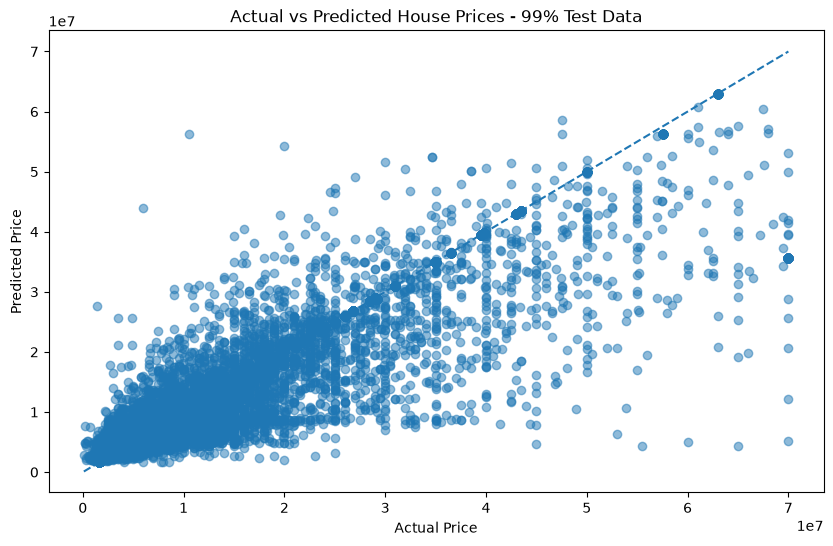

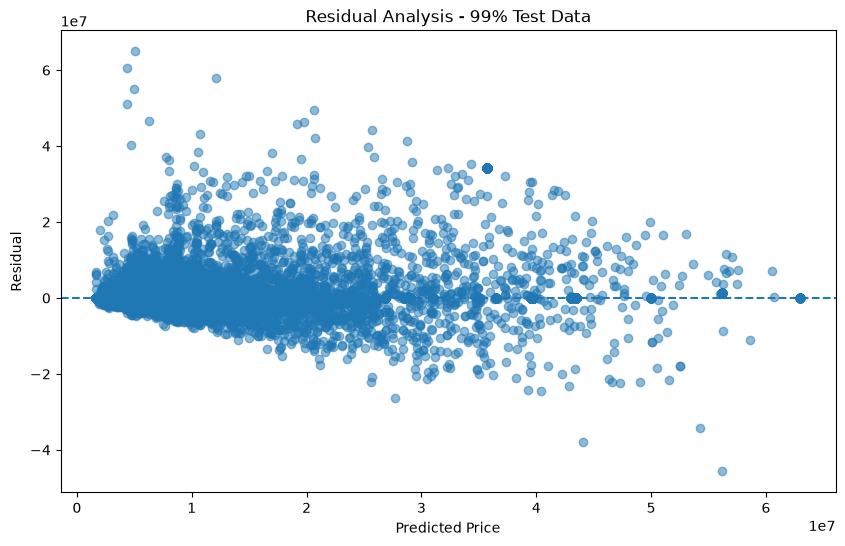

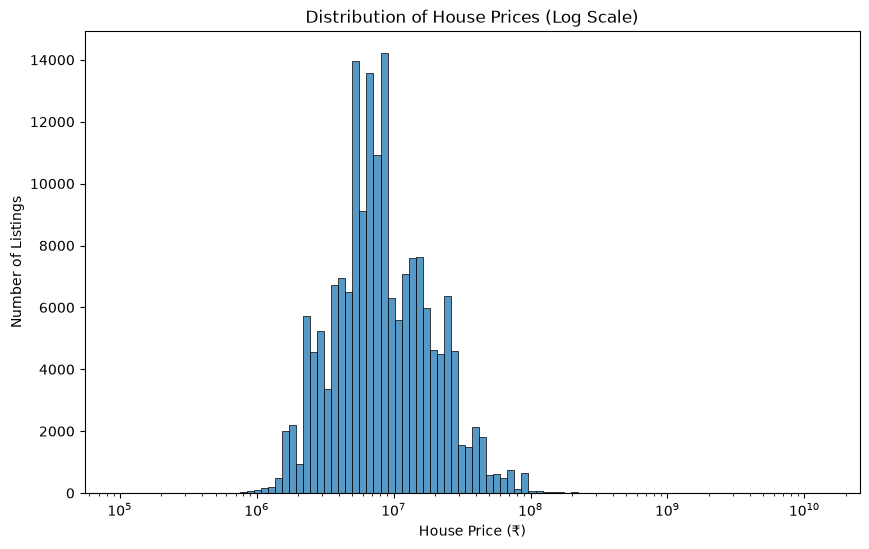

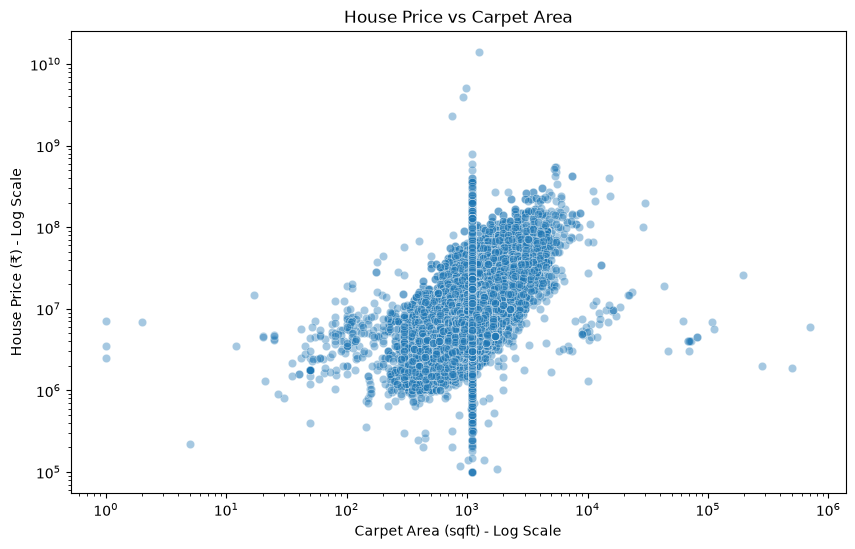

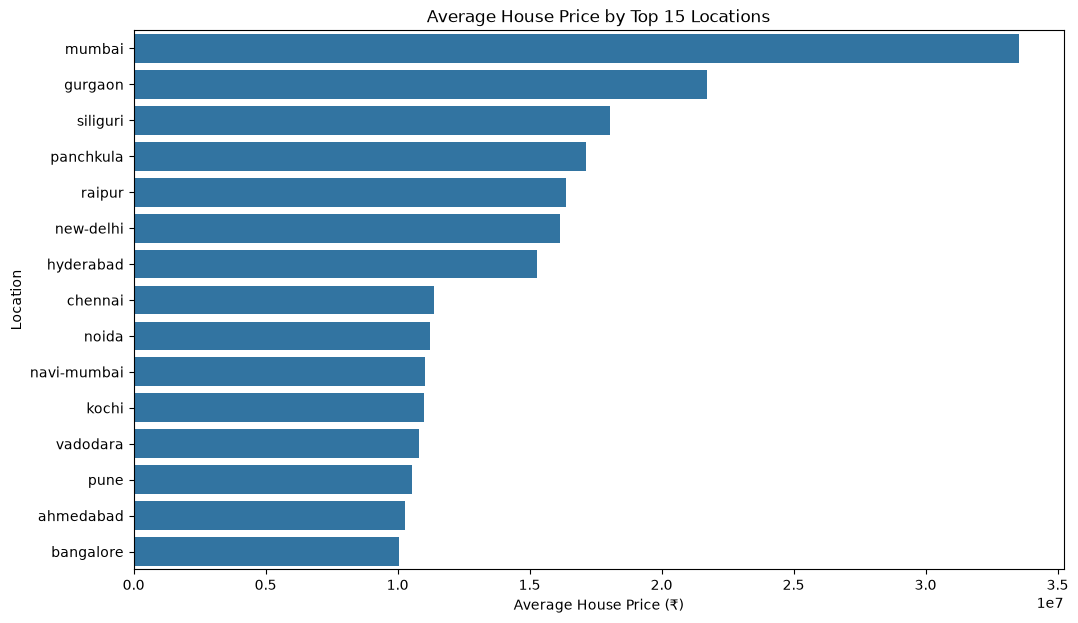

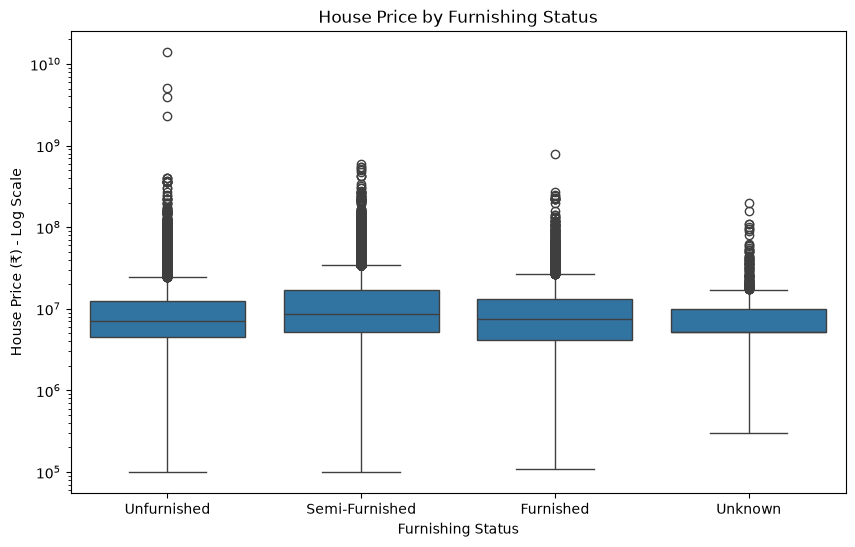


Model saved successfully:
../models/house_price.pkl
Locations saved successfully:
../models/locations.json


NEW HOUSE PREDICTION
Predicted House Price: ₹ 5,981,071.19


FINAL SUMMARY
Dataset shape: (177847, 10)
Random Forest R²: 0.0199
Random Forest R² (99%): 0.8624
Linear Regression R²: -0.0685
Linear Regression R² (99%): 0.2635
Best Model: Random Forest
Predicted New House Price: ₹ 5,981,071.19

DONE ✅


In [23]:
# ============================================================
# HOUSE PRICE PREDICTION - COMPLETE PIPELINE
# Cleaning + EDA + Random Forest + Linear Regression
# Evaluation + Plots + Model Saving + New Prediction
# ============================================================

import os
import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("../data/house_prices.csv")

print("=" * 60)
print("DATASET LOADED")
print("=" * 60)
print("Shape:", df.shape)


# ============================================================
# 2. CLEAN PRICE
# ============================================================

def parse_amount(x):
    if not isinstance(x, str):
        return None

    x = x.strip().lower()

    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 100000

        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 10000000

        return float(x.replace(",", ""))

    except ValueError:
        return None


df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)

df = df.dropna(subset=["price_clean"]).copy()


# ============================================================
# 3. CLEAN CARPET AREA
# ============================================================

def parse_area(x):
    if not isinstance(x, str):
        return None

    x = x.strip().lower()

    try:
        if "sqm" in x:
            value = float(x.replace("sqm", "").strip())
            return value * 10.764

        if "sqft" in x:
            return float(x.replace("sqft", "").strip())

        return float(x.replace(",", ""))

    except ValueError:
        return None


df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)


# ============================================================
# 4. CLEAN FLOOR
# ============================================================

def parse_floor(x):
    if not isinstance(x, str):
        return None

    x = x.strip().lower()

    if "ground" in x:
        return 0

    try:
        return float(x.split(" out of ")[0].strip())

    except (ValueError, IndexError):
        return None


df["floor_num"] = df["Floor"].apply(parse_floor)


# ============================================================
# 5. NUMERICAL CLEANING
# ============================================================

df["Bathroom"] = pd.to_numeric(
    df["Bathroom"], errors="coerce"
)

df["Balcony"] = pd.to_numeric(
    df["Balcony"], errors="coerce"
)

df["Bathroom"] = df["Bathroom"].fillna(
    df["Bathroom"].median()
)

df["Balcony"] = df["Balcony"].fillna(
    df["Balcony"].median()
)

df["floor_num"] = df["floor_num"].fillna(
    df["floor_num"].median()
)

df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(
    df["carpet_area_sqft"].median()
)


# ============================================================
# 6. CATEGORICAL CLEANING
# ============================================================

for col in [
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing"
]:
    df[col] = df[col].fillna("Unknown")


# ============================================================
# 7. GROUP LOCATIONS
# ============================================================

top_locations = (
    df["location"]
    .value_counts()
    .head(50)
    .index
)

df["location_grouped"] = df["location"].where(
    df["location"].isin(top_locations),
    "Other"
)


# ============================================================
# 8. DROP UNNECESSARY COLUMNS
# ============================================================

columns_to_drop = [
    "Index",
    "Title",
    "Description",
    "Price (in rupees)",
    "Plot Area",
    "Dimensions",
    "Society",
    "Super Area",
    "Car Parking",
    "overlooking",
    "Status",
    "Carpet Area",
    "Floor",
    "location",
    "Amount(in rupees)"
]

df = df.drop(
    columns=columns_to_drop,
    errors="ignore"
)


print("\nCleaned dataset shape:", df.shape)


# ============================================================
# 9. FEATURES + TARGET
# ============================================================

X = df.drop(columns=["price_clean"])
y = df["price_clean"]

categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_cols = X.select_dtypes(
    exclude=["object"]
).columns.tolist()


# ============================================================
# 10. PREPROCESSOR
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numerical_cols
        ),

        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ]
)


# ============================================================
# 11. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 12. LOG TRANSFORM
# ============================================================

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)


# ============================================================
# 13. REMOVE EXTREME TRAINING OUTLIERS
# ============================================================

lower_limit = y_train_log.quantile(0.01)
upper_limit = y_train_log.quantile(0.99)

train_mask = (
    (y_train_log >= lower_limit) &
    (y_train_log <= upper_limit)
)

X_train_clean = X_train.loc[train_mask]
y_train_clean = y_train_log.loc[train_mask]


print("\nTraining samples before outliers:",
      len(y_train))

print("Training samples after outliers:",
      len(y_train_clean))


# ============================================================
# 14. RANDOM FOREST
# ============================================================

rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "regressor",
            RandomForestRegressor(
                n_estimators=100,
                max_depth=20,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


print("\nTraining Random Forest...")

start = time.time()

rf_model.fit(
    X_train_clean,
    y_train_clean
)

rf_training_time = time.time() - start

print(
    f"Random Forest training time: "
    f"{rf_training_time:.2f} seconds"
)


# ============================================================
# 15. RANDOM FOREST PREDICTION
# ============================================================

rf_pred_log = rf_model.predict(X_test)

rf_pred = np.expm1(rf_pred_log)

y_test_original = np.expm1(y_test_log)


# ============================================================
# 16. RANDOM FOREST METRICS
# ============================================================

rf_mae = mean_absolute_error(
    y_test_original,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test_original,
    rf_pred
)


# ============================================================
# 17. LINEAR REGRESSION
# ============================================================

linear_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "regressor",
            LinearRegression()
        )
    ]
)


print("\nTraining Linear Regression...")

start = time.time()

linear_model.fit(
    X_train_clean,
    y_train_clean
)

linear_training_time = time.time() - start

print(
    f"Linear Regression training time: "
    f"{linear_training_time:.2f} seconds"
)


# ============================================================
# 18. LINEAR PREDICTION
# ============================================================

linear_pred_log = linear_model.predict(X_test)

linear_pred = np.expm1(linear_pred_log)


# ============================================================
# 19. LINEAR METRICS
# ============================================================

linear_mae = mean_absolute_error(
    y_test_original,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        linear_pred
    )
)

linear_r2 = r2_score(
    y_test_original,
    linear_pred
)


# ============================================================
# 20. MODEL COMPARISON
# ============================================================

model_comparison = pd.DataFrame({

    "Model": [
        "Random Forest",
        "Linear Regression"
    ],

    "MAE": [
        rf_mae,
        linear_mae
    ],

    "RMSE": [
        rf_rmse,
        linear_rmse
    ],

    "R2": [
        rf_r2,
        linear_r2
    ]
})


print("\n")
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

display(model_comparison)


# ============================================================
# 21. EVALUATION ON 99% TEST DATA
# ============================================================

test_upper_limit = y_test_original.quantile(0.99)

normal_mask = (
    y_test_original <= test_upper_limit
)

y_test_normal = y_test_original[
    normal_mask
]

rf_pred_normal = rf_pred[
    normal_mask
]

linear_pred_normal = linear_pred[
    normal_mask
]


# Random Forest 99%

rf_mae_99 = mean_absolute_error(
    y_test_normal,
    rf_pred_normal
)

rf_rmse_99 = np.sqrt(
    mean_squared_error(
        y_test_normal,
        rf_pred_normal
    )
)

rf_r2_99 = r2_score(
    y_test_normal,
    rf_pred_normal
)


# Linear Regression 99%

lr_mae_99 = mean_absolute_error(
    y_test_normal,
    linear_pred_normal
)

lr_rmse_99 = np.sqrt(
    mean_squared_error(
        y_test_normal,
        linear_pred_normal
    )
)

lr_r2_99 = r2_score(
    y_test_normal,
    linear_pred_normal
)


comparison_99 = pd.DataFrame({

    "Model": [
        "Random Forest",
        "Linear Regression"
    ],

    "MAE": [
        rf_mae_99,
        lr_mae_99
    ],

    "RMSE": [
        rf_rmse_99,
        lr_rmse_99
    ],

    "R2": [
        rf_r2_99,
        lr_r2_99
    ]
})


print("\n")
print("=" * 60)
print("MODEL COMPARISON - 99% TEST DATA")
print("=" * 60)

display(comparison_99)


# ============================================================
# 22. SELECT BEST MODEL
# ============================================================

best_model_row = comparison_99.loc[
    comparison_99["R2"].idxmax()
]

best_model_name = best_model_row["Model"]


print("\n")
print("=" * 60)
print("BEST MODEL")
print("=" * 60)

print(best_model_row)


# ============================================================
# 23. FEATURE IMPORTANCE - RANDOM FOREST
# ============================================================

fitted_preprocessor = (
    rf_model.named_steps["preprocessor"]
)

fitted_rf = (
    rf_model.named_steps["regressor"]
)

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

importances = fitted_rf.feature_importances_

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importances

}).sort_values(
    "Importance",
    ascending=False
)


print("\nTop 15 Important Features:")

display(
    importance_df.head(15)
)


# ============================================================
# 24. PLOT - ACTUAL VS PREDICTED
# ============================================================

evaluation_99 = pd.DataFrame({

    "Actual": y_test_normal.values,

    "Predicted": rf_pred_normal
})


plt.figure(figsize=(10, 6))

plt.scatter(
    evaluation_99["Actual"],
    evaluation_99["Predicted"],
    alpha=0.5
)

min_value = min(
    evaluation_99["Actual"].min(),
    evaluation_99["Predicted"].min()
)

max_value = max(
    evaluation_99["Actual"].max(),
    evaluation_99["Predicted"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(
    "Actual vs Predicted House Prices - 99% Test Data"
)

plt.show()


# ============================================================
# 25. RESIDUAL ANALYSIS
# ============================================================

evaluation_99["Residual"] = (
    evaluation_99["Actual"]
    - evaluation_99["Predicted"]
)


plt.figure(figsize=(10, 6))

plt.scatter(
    evaluation_99["Predicted"],
    evaluation_99["Residual"],
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title(
    "Residual Analysis - 99% Test Data"
)

plt.show()


# ============================================================
# 26. PRICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["price_clean"],
    bins=100,
    log_scale=True
)

plt.xlabel("House Price (₹)")
plt.ylabel("Number of Listings")
plt.title(
    "Distribution of House Prices (Log Scale)"
)

plt.show()


# ============================================================
# 27. PRICE VS CARPET AREA
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="carpet_area_sqft",
    y="price_clean",
    alpha=0.4
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(
    "Carpet Area (sqft) - Log Scale"
)

plt.ylabel(
    "House Price (₹) - Log Scale"
)

plt.title(
    "House Price vs Carpet Area"
)

plt.show()


# ============================================================
# 28. TOP LOCATIONS
# ============================================================

top_15_locations = (
    df.groupby("location_grouped")["price_clean"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)


plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_15_locations.values,
    y=top_15_locations.index
)

plt.xlabel("Average House Price (₹)")
plt.ylabel("Location")
plt.title(
    "Average House Price by Top 15 Locations"
)

plt.show()


# ============================================================
# 29. PRICE BY FURNISHING
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Furnishing",
    y="price_clean"
)

plt.yscale("log")

plt.xlabel("Furnishing Status")
plt.ylabel(
    "House Price (₹) - Log Scale"
)

plt.title(
    "House Price by Furnishing Status"
)

plt.show()


# ============================================================
# 30. SAVE BEST MODEL
# ============================================================

os.makedirs("../models", exist_ok=True)

if best_model_name == "Random Forest":

    final_model = rf_model

else:

    final_model = linear_model


joblib.dump(
    final_model,
    "../models/house_price.pkl"
)


print("\nModel saved successfully:")
print("../models/house_price.pkl")


# ============================================================
# 31. SAVE LOCATIONS
# ============================================================

locations_list = sorted(
    df["location_grouped"]
    .unique()
    .tolist()
)


with open(
    "../models/locations.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        locations_list,
        f,
        ensure_ascii=False,
        indent=4
    )


print("Locations saved successfully:")
print("../models/locations.json")


# ============================================================
# 32. TEST NEW HOUSE
# ============================================================

new_house = pd.DataFrame({

    "Bathroom": [2],

    "Balcony": [1],

    "carpet_area_sqft": [1200],

    "floor_num": [5],

    "Transaction": ["Resale"],

    "Furnishing": ["Semi-Furnished"],

    "facing": ["East"],

    "Ownership": ["Freehold"],

    "location_grouped": ["Mumbai"]

})


prediction_log = final_model.predict(
    new_house
)


predicted_price = np.expm1(
    prediction_log
)[0]


print("\n")
print("=" * 60)
print("NEW HOUSE PREDICTION")
print("=" * 60)

print(
    f"Predicted House Price: ₹ {predicted_price:,.2f}"
)


# ============================================================
# 33. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print("Dataset shape:", df.shape)

print(
    f"Random Forest R²: {rf_r2:.4f}"
)

print(
    f"Random Forest R² (99%): {rf_r2_99:.4f}"
)

print(
    f"Linear Regression R²: {linear_r2:.4f}"
)

print(
    f"Linear Regression R² (99%): {lr_r2_99:.4f}"
)

print(
    f"Best Model: {best_model_name}"
)

print(
    f"Predicted New House Price: "
    f"₹ {predicted_price:,.2f}"
)

print("\nDONE ✅")